![Tower Bridge in London](tower_bridge.jpeg)

# London Temperature Intelligence with MLflow

## Project Description

As the climate changes around the world, the ability to predict changing weather is becoming more and more important.

In this project, we predict the mean temperature in London. We import, preprocess, and explore historical weather data, then automate the training and evaluation of multiple machine-learning models in a workflow built with functions, scikit-learn, and MLflow.

The dataset contains daily measurements for date, cloud cover, sunshine, global radiation, maximum/mean/minimum temperature, precipitation, pressure, and snow depth.

## Project workflow

1. Load and inspect the data.
2. Clean the date and derive calendar features.
3. Explore temperature trends and feature correlations.
4. Select predictive features.
5. Split, impute, and scale the data without leakage.
6. Train and log several regression models with MLflow.
7. Search the logged runs and identify the best result.

## 1. Environment setup

Run the installation cell before the imports. It installs the tested dependency versions into the Python environment used by the active notebook kernel. If packages are installed for the first time, restart the kernel once before continuing.

In [1]:
# Install packages with the exact Python executable used by this notebook kernel.
# Using sys.executable prevents pip from installing into a different Python environment.
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy==2.1.3",
    "pandas==2.3.3",
    "matplotlib==3.11.0",
    "scikit-learn==1.5.2",
    "mlflow==2.17.2",
    "ipykernel==7.3.0",
]

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "--quiet", *REQUIRED_PACKAGES]
)

print("Dependencies are ready. Python executable:", sys.executable)
print("Restart the kernel now only if these packages were installed for the first time.")

Dependencies are ready. Python executable: /Users/ET35771/Documents/AI/DataCamp tuto/Machine Learning Engineer/.venv/bin/python
Restart the kernel now only if these packages were installed for the first time.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Standard-library tools used for structured reports and temporary artifacts.
import json
import tempfile

# Path makes file locations portable across operating systems.
from pathlib import Path

# MLflow records each experiment, metric, parameter, and fitted model.
import mlflow
import mlflow.sklearn
from mlflow import MlflowClient
from mlflow.models import infer_signature

# Core libraries for data manipulation and visualization.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn tools used for preprocessing, training, and evaluation.
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# Apply consistent chart styling and show every DataFrame column.
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 2. Loading the data

Load `london_weather.csv`, inspect a sample, and review column types and missing values.

In [3]:
# The CSV is stored next to this notebook.
DATA_PATH = Path("london_weather.csv")

# Load the daily London weather measurements into a DataFrame.
weather = pd.read_csv(DATA_PATH)

# Inspect the size, first rows, column types, and non-null counts.
print(f"Shape: {weather.shape[0]:,} rows × {weather.shape[1]} columns")
display(weather.head())
weather.info()

Shape: 15,341 rows × 10 columns


,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


## 3. Data cleaning

The raw `date` column uses the `YYYYMMDD` format. Convert it to `datetime`, then derive `year` and `month` for analysis. Missing target values cannot be used for supervised learning, so they are removed before modeling; missing feature values will be handled later by an imputer fitted only on the training set.

In [4]:
# Work on a copy so the raw DataFrame is not modified unexpectedly.
weather = weather.copy()

# Parse integer dates such as 19790101 with the explicit YYYYMMDD format.
weather["date"] = pd.to_datetime(weather["date"], format="%Y%m%d")

# Calendar columns make long-term trends and seasonality easier to study.
weather["year"] = weather["date"].dt.year
weather["month"] = weather["date"].dt.month

# Keep only columns containing at least one missing value.
missing_values = (
    weather.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
    .query("missing_values > 0")
)
display(missing_values)
print(f"Date range: {weather['date'].min().date()} to {weather['date'].max().date()}")

,missing_values
cloud_cover,19
global_radiation,19
max_temp,6
mean_temp,36
min_temp,2
precipitation,6
pressure,4
snow_depth,1441


Date range: 1979-01-01 to 2020-12-31


## 4. Exploratory data analysis

Visualize the long-term mean-temperature trend, monthly seasonality, and correlations between numeric variables.

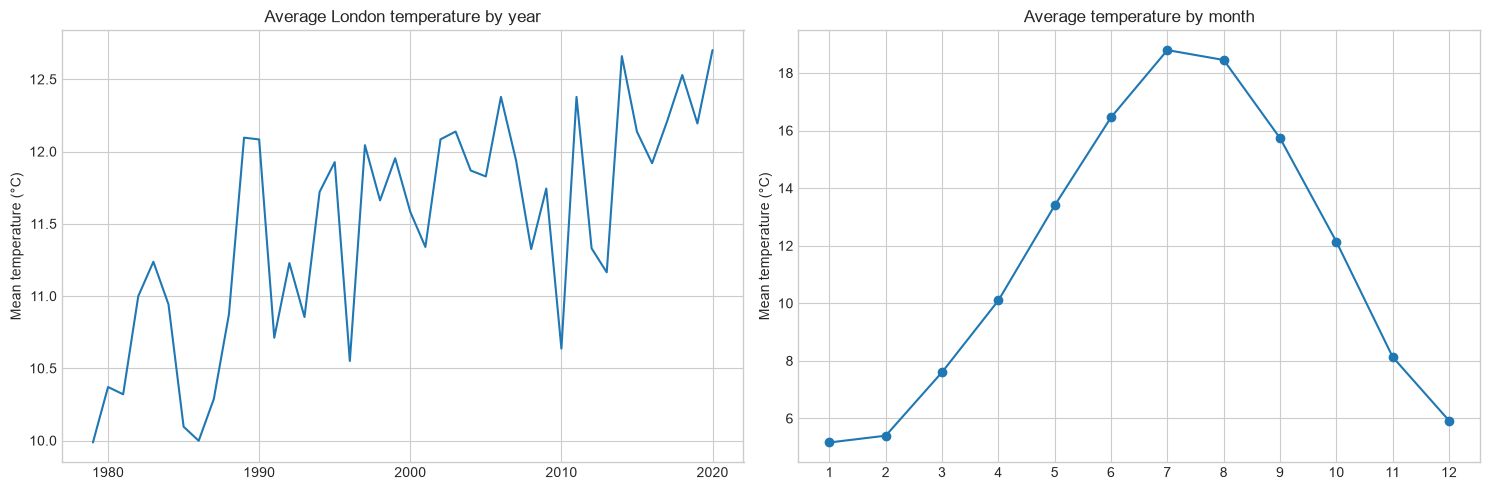

In [5]:
# Create two charts: yearly trend and average monthly seasonality.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Aggregate daily measurements to one mean temperature per year.
yearly_temperature = weather.groupby("year", as_index=False)["mean_temp"].mean()
axes[0].plot(
    yearly_temperature["year"],
    yearly_temperature["mean_temp"],
)
axes[0].set(title="Average London temperature by year", ylabel="Mean temperature (°C)")

# Aggregate all years to obtain the typical temperature for each month.
monthly_temperature = weather.groupby("month", as_index=False)["mean_temp"].mean()
axes[1].plot(
    monthly_temperature["month"],
    monthly_temperature["mean_temp"],
    marker="o",
)
axes[1].set(title="Average temperature by month", ylabel="Mean temperature (°C)", xticks=range(1, 13))

plt.tight_layout()
plt.show()

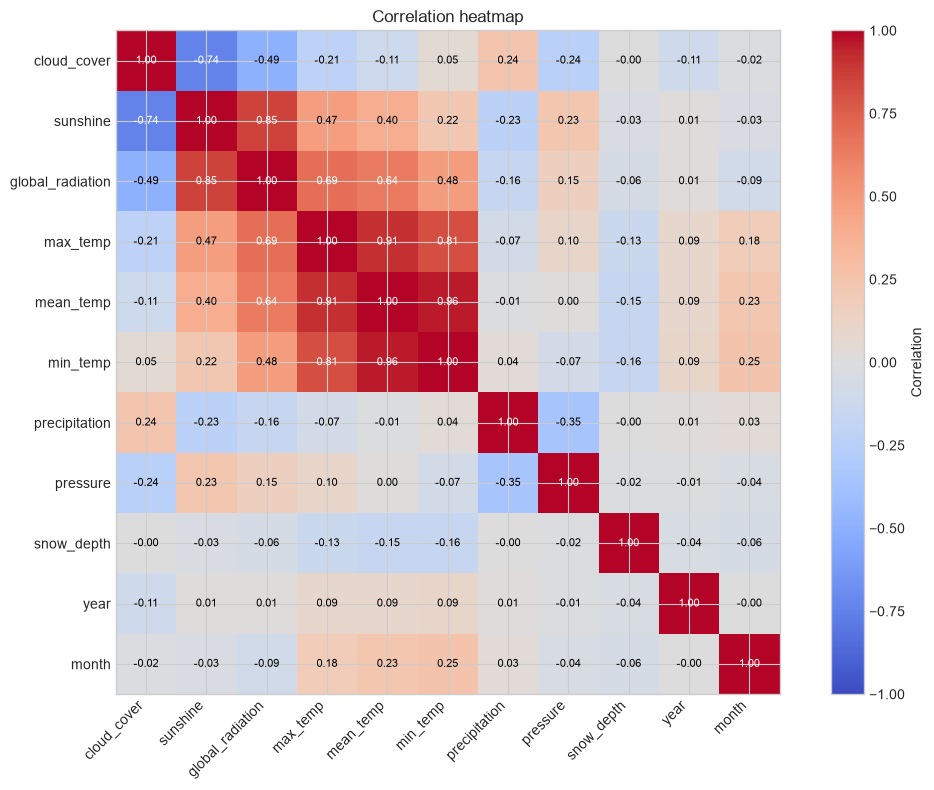

,correlation_with_mean_temp
min_temp,0.955593
max_temp,0.912200
global_radiation,0.635432
sunshine,0.396535
month,0.227076
snow_depth,-0.154945
cloud_cover,-0.110556
year,0.093743
precipitation,-0.010462
pressure,0.004764


In [6]:
# Correlations require numeric columns, so the datetime column is excluded.
numeric_weather = weather.select_dtypes(include="number")
correlations = numeric_weather.corr()

# The heatmap provides a visual overview of all pairwise correlations.
fig, ax = plt.subplots(figsize=(11, 8))
heatmap = ax.imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlations.columns)), correlations.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlations.index)), correlations.index)

# Write each correlation value inside its heatmap cell.
for row in range(len(correlations.index)):
    for column in range(len(correlations.columns)):
        value = correlations.iloc[row, column]
        text_color = "white" if abs(value) > 0.55 else "black"
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

fig.colorbar(heatmap, ax=ax, label="Correlation")
ax.set_title("Correlation heatmap")
plt.tight_layout()
plt.show()

# Rank features by absolute correlation with the prediction target.
target_correlations = (
    correlations["mean_temp"]
    .drop("mean_temp")
    .sort_values(key=np.abs, ascending=False)
)
display(target_correlations.rename("correlation_with_mean_temp").to_frame())

## 5. Feature selection

`min_temp`, `max_temp`, and `global_radiation` have the strongest absolute correlations with `mean_temp`. They form a compact and interpretable feature set for the regression comparison.

In [7]:
# Choose a compact feature set with strong relationships to mean_temp.
feature_selection = ["min_temp", "max_temp", "global_radiation"]
target = "mean_temp"

# Rows with a missing target cannot be used in supervised learning.
# Missing feature values are retained and handled by the imputer below.
model_data = weather.dropna(subset=[target]).copy()
X = model_data[feature_selection]
y = model_data[target]

print("Selected features:", feature_selection)
print(f"Modeling rows: {len(model_data):,}")

Selected features: ['min_temp', 'max_temp', 'global_radiation']
Modeling rows: 15,305


## 6. Preprocess data

Split before fitting preprocessing objects. The imputer and scaler learn only from the training data, preventing information from the test set from leaking into model training.

In [8]:
# Reserve 20% of the observations for an unbiased final evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

# Learn replacement values from the training data only.
imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Learn scaling statistics from training data, then reuse them on test data.
scaler = StandardScaler()
# Restore column names after scikit-learn returns NumPy arrays.
# Named columns make MLflow signatures and later inference clearer.
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=feature_selection,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=feature_selection,
    index=X_test.index,
)

print("Training shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Training shape: (12244, 3)
Test shape: (3061, 3)


## 7. Machine-learning training and evaluation with MLflow

For each candidate tree depth, start one MLflow run and train three regressors: linear regression, a decision tree, and a random forest. Log the configuration, fitted model artifacts, and each model's test RMSE.

In [9]:
# Store experiment metadata in a local SQLite database beside the notebook.
TRACKING_DB = Path("london_temperature_mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{TRACKING_DB}")

# All comparison runs are grouped under one named experiment.
EXPERIMENT_NAME = "London Temperature Prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME)

Tracking URI: sqlite:////Users/ET35771/Documents/AI/DataCamp tuto/Machine Learning Engineer/London Temperature Intelligence with MLflow/london_temperature_mlflow.db
Experiment: London Temperature Prediction


In [10]:
def train_evaluate_and_log(depth, X_train, X_test, y_train, y_test):
    """Train candidate regressors, log their models, and return test RMSE values."""
    # Linear regression is the baseline; tree depth affects the other models.
    models = {
        "linear_regression": LinearRegression(),
        "decision_tree": DecisionTreeRegressor(
            max_depth=depth, random_state=RANDOM_STATE
        ),
        "random_forest": RandomForestRegressor(
            n_estimators=100, max_depth=depth, random_state=RANDOM_STATE, n_jobs=-1
        ),
    }

    # Train, predict, evaluate, and log every candidate model.
    rmse_results = {}
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        # RMSE is expressed in °C and penalizes large prediction errors.
        rmse = float(np.sqrt(mean_squared_error(y_test, predictions)))

        # A signature documents expected columns and prediction data types.
        signature = infer_signature(X_train, model.predict(X_train))
        mlflow.sklearn.log_model(
            model,
            artifact_path=model_name,
            signature=signature,
            input_example=X_train.head(3),
        )
        mlflow.log_metric(f"rmse_{model_name}", rmse)
        rmse_results[model_name] = rmse

    return rmse_results

In [11]:
# Keep a compact local summary in addition to MLflow's stored run data.
experiment_summary = []

# Compare shallow, medium, and deeper tree configurations.
for idx, depth in enumerate([1, 2, 10]):
    run_name = f"run_{idx}_depth_{depth}"

    # The context manager always closes the MLflow run correctly.
    with mlflow.start_run(run_name=run_name) as run:
        # Parameters describe the configuration chosen before training.
        mlflow.log_param("max_depth", depth)
        mlflow.log_param("features", ",".join(feature_selection))
        mlflow.log_param("test_size", 0.20)
        # Tags add searchable context without acting as model parameters.
        mlflow.set_tag("target", target)
        mlflow.set_tag("workflow", "regression-model-comparison")

        run_metrics = train_evaluate_and_log(
            depth,
            X_train_scaled,
            X_test_scaled,
            y_train,
            y_test,
        )

        experiment_summary.append(
            {"run_id": run.info.run_id, "run_name": run_name, "max_depth": depth, **run_metrics}
        )

summary_df = pd.DataFrame(experiment_summary)
display(summary_df)

,run_id,run_name,max_depth,linear_regression,decision_tree,random_forest
0,8db56e86d3b348d79b9c4322ff2db461,run_0_depth_1,1,0.898297,3.407016,3.280442
1,edf9aa3b99c147b28a30d89b6e433283,run_1_depth_2,2,0.898297,2.329430,2.224354
2,c0127570636144dbbc188b6660c43cba,run_2_depth_10,10,0.898297,1.020834,0.894392


### Interpreting the training results

#### What does RMSE mean?

The **root mean squared error (RMSE)** measures the typical distance between predicted and observed temperatures. Because the target is measured in degrees Celsius, RMSE is also expressed in **°C**. A smaller value is better. An RMSE of `0.894` means that predictions differ from the recorded mean temperature by roughly **0.9 °C**, while larger individual errors receive an additional penalty because the errors are squared.

| `max_depth` | Linear regression | Decision tree | Random forest | Interpretation |
|---:|---:|---:|---:|---|
| 1 | 0.898 °C | 3.407 °C | 3.280 °C | Depth 1 is too restrictive for tree models; both strongly underfit. |
| 2 | 0.898 °C | 2.329 °C | 2.224 °C | Extra depth captures more structure, but the trees still underfit. |
| 10 | 0.898 °C | 1.021 °C | **0.894 °C** | Deeper trees capture nonlinear relationships; the forest gives the lowest test error. |

#### Why is linear regression identical in every run?

`max_depth` applies only to the decision tree and random forest. The linear-regression model, training data, and test data are unchanged across the three runs, so its RMSE remains `0.898297` each time. Repeating it is still useful because every MLflow run then contains a common baseline for comparison.

#### What do the tree results show?

Increasing `max_depth` from 1 to 10 substantially reduces RMSE. The shallow models have **high bias**, also called underfitting: they are too simple to represent the relationship between the selected variables and mean temperature. The random forest performs better than a single decision tree at depth 10 because it averages many trees, reducing the instability and variance of an individual tree.

#### Is the random forest clearly superior?

Only marginally. Its RMSE (`0.894392 °C`) improves on linear regression (`0.898297 °C`) by about `0.0039 °C`, or roughly **0.4%**. That difference is very small, so linear regression remains an attractive baseline: it is simpler, faster, and easier to explain. A stronger conclusion would require repeated or time-based cross-validation rather than one random train/test split.

> **Important modeling caveat:** `min_temp` and `max_temp` are measurements from the same day as `mean_temp`. This notebook therefore estimates mean temperature from related daily observations; it is not yet a true future-weather forecast. A forecasting system should use only information available before prediction time, such as lagged temperatures, previous-day weather, month, and rolling statistics.

## 8. Production-grade MLflow workflow

The first experiment demonstrates the DataCamp workflow. This section strengthens it for a portfolio project by applying several MLOps practices:

- package preprocessing and estimation in one scikit-learn `Pipeline`;
- create one MLflow run per candidate configuration;
- record dataset lineage, parameters, tags, metrics, signatures, and input examples;
- log residual plots, feature-importance tables, and evaluation reports;
- select the best candidate through a searchable metric;
- register the approved artifact and expose it through a movable `champion` alias.

This makes the logged model self-contained: consumers can send raw feature columns without manually repeating the training transformations.

In [12]:
def build_model_pipeline(estimator):
    """Return a portable pipeline that owns preprocessing and prediction."""
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("regressor", estimator),
        ]
    )


def regression_metrics(y_true, y_pred):
    """Return complementary regression metrics in business-friendly units."""
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def log_evaluation_artifacts(model, X_eval, y_eval, predictions, model_name):
    """Log reusable evaluation evidence for one candidate model."""
    residuals = y_eval.to_numpy() - predictions

    # Residual plots reveal bias, outliers, and changing error variance.
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(predictions, residuals, alpha=0.25, s=12)
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set(
        title=f"Residuals — {model_name}",
        xlabel="Predicted mean temperature (°C)",
        ylabel="Observed − predicted (°C)",
    )
    axes[1].hist(residuals, bins=35, edgecolor="white")
    axes[1].set(title="Residual distribution", xlabel="Residual (°C)")
    plt.tight_layout()
    mlflow.log_figure(fig, "evaluation/residual_analysis.png")
    plt.close(fig)

    # Save row-level predictions for later error analysis.
    prediction_report = X_eval.copy()
    prediction_report["observed_mean_temp"] = y_eval.to_numpy()
    prediction_report["predicted_mean_temp"] = predictions
    prediction_report["residual"] = residuals

    with tempfile.TemporaryDirectory() as temporary_directory:
        report_path = Path(temporary_directory) / "test_predictions.csv"
        prediction_report.to_csv(report_path, index=False)
        mlflow.log_artifact(str(report_path), artifact_path="evaluation")

    # Tree models expose feature_importances_; linear regression exposes coefficients.
    fitted_regressor = model.named_steps["regressor"]
    if hasattr(fitted_regressor, "feature_importances_"):
        importance_values = fitted_regressor.feature_importances_
        importance_type = "feature_importance"
    elif hasattr(fitted_regressor, "coef_"):
        importance_values = np.abs(np.ravel(fitted_regressor.coef_))
        importance_type = "absolute_coefficient"
    else:
        return

    importance_table = (
        pd.DataFrame({"feature": feature_selection, importance_type: importance_values})
        .sort_values(importance_type, ascending=False)
        .reset_index(drop=True)
    )
    mlflow.log_table(importance_table, "evaluation/feature_importance.json")

In [13]:
# Each candidate gets its own run, making comparisons and promotion unambiguous.
candidate_estimators = {
    "linear_regression": LinearRegression(),
    "decision_tree_depth_3": DecisionTreeRegressor(
        max_depth=3, random_state=RANDOM_STATE
    ),
    "decision_tree_depth_10": DecisionTreeRegressor(
        max_depth=10, random_state=RANDOM_STATE
    ),
    "random_forest_depth_5": RandomForestRegressor(
        n_estimators=100, max_depth=5, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "random_forest_depth_10": RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

# MLflow records the training dataset identity and schema with every candidate.
training_frame = X_train.copy()
training_frame[target] = y_train
training_dataset = mlflow.data.from_pandas(
    training_frame,
    source=str(DATA_PATH.resolve()),
    name="london_weather_training_set",
    targets=target,
)

for candidate_name, estimator in candidate_estimators.items():
    with mlflow.start_run(run_name=f"candidate_{candidate_name}"):
        model_pipeline = build_model_pipeline(estimator)
        model_pipeline.fit(X_train, y_train)
        candidate_predictions = model_pipeline.predict(X_test)
        candidate_metrics = regression_metrics(y_test, candidate_predictions)

        # Parameters, tags, and dataset input make the run searchable and auditable.
        mlflow.log_params(
            {
                "candidate_name": candidate_name,
                "estimator_class": estimator.__class__.__name__,
                "feature_count": len(feature_selection),
                "imputation_strategy": "mean",
                "scaling": "StandardScaler",
                **estimator.get_params(),
            }
        )
        mlflow.set_tags(
            {
                "project": "predicting-temperature-in-london",
                "project_phase": "production-candidate",
                "validation_strategy": "random-holdout",
                "owner": "mohamed-habib-jaberi",
            }
        )
        mlflow.log_input(training_dataset, context="training")
        mlflow.log_metrics(candidate_metrics)
        mlflow.log_dict(
            {
                "features": feature_selection,
                "target": target,
                "training_rows": len(X_train),
                "test_rows": len(X_test),
                "limitations": [
                    "Random holdout is not a substitute for chronological validation.",
                    "Same-day min/max temperature makes this estimation, not future forecasting.",
                ],
            },
            "metadata/model_context.json",
        )

        # The logged model includes preprocessing, schema, and a valid raw input example.
        model_signature = infer_signature(X_train, model_pipeline.predict(X_train))
        mlflow.sklearn.log_model(
            model_pipeline,
            artifact_path="model",
            signature=model_signature,
            input_example=X_train.head(5),
        )
        log_evaluation_artifacts(
            model_pipeline, X_test, y_test, candidate_predictions, candidate_name
        )

/Users/ET35771/.pyenv/versions/3.12.2/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:149: UserWarning: Failed to determine whether UCVolumeDatasetSource can resolve source information for '/Users/ET35771/Documents/AI/DataCamp tuto/Machine Learning Engineer/London Temperature Intelligence with MLflow/london_weather.csv'. Exception: 
  return _dataset_source_registry.resolve(
/Users/ET35771/.pyenv/versions/3.12.2/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:149: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


### What a professional MLflow run now contains

| Evidence | Why it matters |
|---|---|
| Parameters | Reconstruct the exact candidate configuration. |
| RMSE, MAE, and R² | Compare error magnitude and explained variance. |
| Dataset input | Connect the model to the training data schema and source. |
| Tags | Search runs by project, lifecycle phase, owner, and validation strategy. |
| Pipeline artifact | Prevent training-serving skew by packaging preprocessing with the estimator. |
| Signature and input example | Document and validate the inference contract. |
| Residual plot and predictions | Support error analysis beyond one summary metric. |
| Feature importance | Explain which inputs most influence predictions. |
| Limitations metadata | Prevent the model from being presented as a future forecast without evidence. |

## 9. Searching the logged results

Use `mlflow.search_runs()` to collect run metadata, parameters, and metrics in a DataFrame ordered by the random forest RMSE.

In [14]:
# Retrieve every run in the experiment and rank by random-forest RMSE.
experiment_results = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    filter_string="tags.workflow = 'regression-model-comparison'",
    order_by=["metrics.rmse_random_forest ASC"],
)

# Display only the columns needed to compare configurations and metrics.
result_columns = [
    "run_id",
    "tags.mlflow.runName",
    "params.max_depth",
    "metrics.rmse_linear_regression",
    "metrics.rmse_decision_tree",
    "metrics.rmse_random_forest",
]
display(experiment_results[result_columns])

,run_id,tags.mlflow.runName,params.max_depth,metrics.rmse_linear_regression,metrics.rmse_decision_tree,metrics.rmse_random_forest
0,c0127570636144dbbc188b6660c43cba,run_2_depth_10,10,0.898297,1.020834,0.894392
1,1d25cb6fbcd4481880939e5416aed80e,run_2_depth_10,10,0.898297,1.020834,0.894392
2,edf9aa3b99c147b28a30d89b6e433283,run_1_depth_2,2,0.898297,2.329430,2.224354
3,f930ea74ba0d4fcbb4d244496331d624,run_1_depth_2,2,0.898297,2.329430,2.224354
4,8db56e86d3b348d79b9c4322ff2db461,run_0_depth_1,1,0.898297,3.407016,3.280442
5,7691cc442cee4ec88164fb153cca6ab8,run_0_depth_1,1,0.898297,3.407016,3.280442


In [15]:
# Locate the row with the smallest random-forest RMSE.
best_run = experiment_results.loc[
    experiment_results["metrics.rmse_random_forest"].idxmin()
]

print("Best random forest run")
print("Run ID:", best_run["run_id"])
print("Run name:", best_run["tags.mlflow.runName"])
print("Max depth:", best_run["params.max_depth"])
print(f"RMSE: {best_run['metrics.rmse_random_forest']:.3f} °C")

Best random forest run
Run ID: c0127570636144dbbc188b6660c43cba
Run name: run_2_depth_10
Max depth: 10
RMSE: 0.894 °C


### Interpreting the MLflow output

- **Run ID** is the unique lineage key for one experiment execution. It retrieves that run's parameters, metrics, tags, and model artifacts.
- **Run name** (`run_2_depth_10`) makes the winning configuration easy to recognize.
- **Max depth 10** identifies the hyperparameter used by the winning tree-based models.
- **RMSE 0.894 °C** is the smallest logged random-forest test error, so MLflow ranks this run first.
- The **Downloading artifacts** progress messages are normal MLflow activity: model files, environment metadata, input examples, and signatures are being assembled and stored. They are not errors.

MLflow does not decide that this model is production-ready. It provides traceability and comparison. Final selection should also consider validation stability, inference cost, explainability, whether the inputs are available at prediction time, and performance on genuinely future observations.

## 10. Select and register the best portable model

Search only the production-candidate runs, rank them by RMSE, and enforce an explicit quality gate before registration. Registration creates an immutable numbered version; the `champion` alias is a movable deployment pointer.

In [16]:
professional_results = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    filter_string="tags.project_phase = 'production-candidate'",
    order_by=["metrics.rmse ASC"],
)

professional_columns = [
    "run_id",
    "tags.mlflow.runName",
    "params.estimator_class",
    "metrics.rmse",
    "metrics.mae",
    "metrics.r2",
]
display(professional_results[professional_columns])

best_candidate = professional_results.iloc[0]
best_candidate_run_id = best_candidate["run_id"]
best_candidate_rmse = float(best_candidate["metrics.rmse"])
best_candidate_r2 = float(best_candidate["metrics.r2"])

# A quality gate makes promotion measurable instead of subjective.
MAX_ACCEPTABLE_RMSE = 1.0
MIN_ACCEPTABLE_R2 = 0.97
quality_gate_passed = (
    best_candidate_rmse <= MAX_ACCEPTABLE_RMSE
    and best_candidate_r2 >= MIN_ACCEPTABLE_R2
)

print("Selected run:", best_candidate_run_id)
print("Candidate:", best_candidate["tags.mlflow.runName"])
print(f"RMSE: {best_candidate_rmse:.3f} °C")
print(f"R²: {best_candidate_r2:.4f}")
print("Quality gate passed:", quality_gate_passed)

,run_id,tags.mlflow.runName,params.estimator_class,metrics.rmse,metrics.mae,metrics.r2
0,5ac17176553c4c6a8cdea2665a830cf2,candidate_random_forest_depth_10,RandomForestRegressor,0.894014,0.692189,0.975509
1,38a4bdcf1be54645a1ff78ee63a47fda,candidate_random_forest_depth_10,RandomForestRegressor,0.894014,0.692189,0.975509
2,a9b22c0e9b194714a94263dfaac7c11d,candidate_linear_regression,LinearRegression,0.898297,0.698279,0.975274
3,2a0cf3fa7ea04731bcfcae2354e06f11,candidate_linear_regression,LinearRegression,0.898297,0.698279,0.975274
4,fee71c927660472b81387c46471cdcfd,candidate_decision_tree_depth_10,DecisionTreeRegressor,1.020834,0.785704,0.968068
5,0c2a32ddbc134950b9a47c7a7e7d43e1,candidate_decision_tree_depth_10,DecisionTreeRegressor,1.020834,0.785704,0.968068
6,995edd56afe3450d94fc3ec4ac65fdd9,candidate_random_forest_depth_5,RandomForestRegressor,1.077286,0.833365,0.964439
7,d7bf6b716ae7441ea419d3062bd3a240,candidate_random_forest_depth_5,RandomForestRegressor,1.077286,0.833365,0.964439
8,8b1a063d2d74499c89768a5dbdbf59ca,candidate_decision_tree_depth_3,DecisionTreeRegressor,1.786969,1.431364,0.902153
9,1e02a8ffa4864d7c958399925aac95b9,candidate_decision_tree_depth_3,DecisionTreeRegressor,1.786969,1.431364,0.902153


Selected run: 5ac17176553c4c6a8cdea2665a830cf2
Candidate: candidate_random_forest_depth_10
RMSE: 0.894 °C
R²: 0.9755
Quality gate passed: True


In [17]:
REGISTERED_MODEL_NAME = "LondonMeanTemperatureRegressor"
client = MlflowClient()

if not quality_gate_passed:
    raise ValueError("The best candidate did not pass the registration quality gate.")

# Register the exact immutable artifact produced by the selected run.
registered_version = mlflow.register_model(
    model_uri=f"runs:/{best_candidate_run_id}/model",
    name=REGISTERED_MODEL_NAME,
)

# The alias can later move to a newer approved version without changing consumers.
client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias="champion",
    version=registered_version.version,
)
client.set_model_version_tag(
    name=REGISTERED_MODEL_NAME,
    version=registered_version.version,
    key="validation_status",
    value="approved_for_demonstration",
)

print("Registered model:", REGISTERED_MODEL_NAME)
print("Version:", registered_version.version)
print("Alias: champion")

Registered model: LondonMeanTemperatureRegressor
Version: 2
Alias: champion


Registered model 'LondonMeanTemperatureRegressor' already exists. Creating a new version of this model...
Created version '2' of model 'LondonMeanTemperatureRegressor'.


In [18]:
# Load through the deployment alias rather than a local Python variable.
champion_uri = f"models:/{REGISTERED_MODEL_NAME}@champion"
champion_model = mlflow.pyfunc.load_model(champion_uri)
champion_predictions = champion_model.predict(X_test.head(5))

champion_validation = X_test.head(5).copy()
champion_validation["observed_mean_temp"] = y_test.head(5).to_numpy()
champion_validation["champion_prediction"] = champion_predictions
display(champion_validation)

# Attach a concise model card to the source run for governance and handoff.
model_card = f"""# London Mean Temperature Model Card

- Registered model: {REGISTERED_MODEL_NAME}
- Version: {registered_version.version}
- Deployment alias: champion
- Source run: {best_candidate_run_id}
- Test RMSE: {best_candidate_rmse:.3f} °C
- Test R²: {best_candidate_r2:.4f}
- Features: {', '.join(feature_selection)}
- Intended use: educational estimation of same-day London mean temperature
- Limitation: not validated as a future-weather forecasting system
"""

with mlflow.start_run(run_id=best_candidate_run_id):
    mlflow.log_text(model_card, "governance/model_card.md")

,min_temp,max_temp,global_radiation,observed_mean_temp,champion_prediction
11784,7.8,21.4,220.0,14.9,14.053156
10079,17.2,28.2,161.0,22.7,21.492364
4397,0.0,7.2,59.0,2.3,3.350393
3477,9.7,18.6,222.0,14.8,14.500749
12151,6.6,11.6,59.0,10.4,9.345770


## 11. Inspect and serve the registered model

Start the MLflow UI from the project directory:

```bash
mlflow ui --backend-store-uri sqlite:///london_temperature_mlflow.db --port 5000
```

Serve the approved alias on a different port:

```bash
mlflow models serve \
  -m "models:/LondonMeanTemperatureRegressor@champion" \
  --env-manager local \
  --host 127.0.0.1 \
  --port 5001
```

Send raw, named features to the inference endpoint:

```bash
curl -X POST http://127.0.0.1:5001/invocations \
  -H "Content-Type: application/json" \
  -d '{
    "dataframe_split": {
      "columns": ["min_temp", "max_temp", "global_radiation"],
      "data": [[8.2, 15.6, 125.0]]
    }
  }'
```

The `/invocations` route requires a POST request; opening it directly in a browser sends GET and is not a valid model test.

## 12. Conclusions and next steps

This workflow connects data inspection, feature selection, leak-free preprocessing, model comparison, artifact logging, and experiment search. For a forecasting use case, the next iteration should use chronological validation and lagged weather features so that every predictor is available before the temperature being predicted.